# Fixed Income Pricing Engine — Building a Bond Pricer from First Principles

A from-scratch implementation of core fixed income pricing tools in Python.

---

## Overview

Bond pricing is one of the most fundamental problems in fixed income. Every Bloomberg terminal, every risk system, every portfolio management tool has this math underneath it. This project builds the pricing engine from scratch: cash flow generation, present value discounting, YTM solving, and sensitivity analysis.

The goal is to understand what's actually happening inside the black box.

---

## What This Builds

1. **Cash flow generator** — Given face value, coupon rate, frequency, and maturity, generate all future cash flows.
2. **Bond pricer** — Discount cash flows back to present value at a given YTM.
3. **YTM solver** — Given a market price, solve for the implied yield using numerical root-finding.
4. **Par/premium/discount verification** — Confirm the price-coupon-yield relationship holds.
5. **Price-yield curve** — Plot how price changes across a range of yields. Explore convexity.

---

## Constraints

- No bond pricing libraries (`QuantLib`, `scipy` bond functions, etc.) — everything built from first principles.
- `scipy.optimize` is allowed for the YTM solver — that's a numerical method, not a bond library.
- Every function has a docstring.

---

## Part 1 — Cash Flow Generator

*Before writing code: what are the cash flows of a bond? List them out in the markdown cell below for a 5-year, 4% annual coupon bond with face value of 1000. Then build a function that generates them.*

**List the cash flows of a 5-year, 4% annual coupon, $1000 face value bond:**

- t1: 40
- t2: 40
- t3: 40
- t4: 40
- t5: 1040

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

def generate_cash_flows(face_value, coupon_rate, frequency, maturity_years):
    """
    Generate bond cash flows.
    
    Parameters:
    -----------
    face_value : float — par value of the bond
    coupon_rate : float — annual coupon rate (e.g. 0.04 for 4%)
    frequency : int — coupon payments per year (1=annual, 2=semi-annual)
    maturity_years : int — years to maturity
    
    Returns:
    --------
    list of (time, cash_flow) tuples
    """
    coupon_payment = face_value * coupon_rate / frequency
    total_periods = maturity_years * frequency
    cash_flows = []

    

    for t in range(1, total_periods+1):
        cash_flow = coupon_payment
        if t == total_periods:
            cash_flow = coupon_payment + face_value
        cash_flows.append((t,cash_flow))
    return cash_flows

In [13]:
# Test it: 5-year, 4% annual coupon, $1000 face value
# Print the cash flows and verify they match what you wrote above

generate_cash_flows(1000, 0.04, 1, 5)


[(1, 40.0), (2, 40.0), (3, 40.0), (4, 40.0), (5, 1040.0)]

**Do the cash flows match your manual calculation? What happens at maturity that's different from the other periods?**

Yes they do match. At maturity date, the face value of the bond is due, which is a payment obligation due to the structure of bonds.


---
## Part 2 — Bond Pricer

*Given a list of cash flows and a YTM, compute the bond price by discounting each cash flow back to present value.*

*Before coding: write the discounting formula for a single cash flow in the markdown cell below.*

**Write the present value formula for a single cash flow CF received at time t, given YTM y and frequency f:**

PV = CF / (1+y/f)^t

In [14]:
def price_bond(cash_flows, ytm, frequency):
    """
    Price a bond by discounting cash flows at YTM.
    
    Parameters:
    -----------
    cash_flows : list of (time, cash_flow) tuples
    ytm : float — yield to maturity (annual, e.g. 0.05 for 5%)
    frequency : int — coupon payments per year
    
    Returns:
    --------
    float — bond price
    """
    price = 0
    for t, cash_flow in cash_flows:
        pv = cash_flow / (1 + ytm / frequency) ** (t)
        price += pv
    return price


In [15]:
# Test: price the 5-year 4% bond at YTMs of 3%, 4%, and 5%
# Before running: what do you expect each price to be relative to par?

# I expect bond to be priced at premium when YTM is 3%, at par at 4% and at discount at 5%.

cash_flows = generate_cash_flows(1000, 0.04, 1, 5)
print(price_bond(cash_flows, 0.03, 1))
print(price_bond(cash_flows, 0.04, 1))
print(price_bond(cash_flows, 0.05, 1))


1045.7970718719453
999.9999999999999
956.7052332936915


**What happened to the price as YTM moved above and below the coupon rate? Does this match your intuition?**

Higher the YTM, the lower the value of the bond, as expected. When YTM < coupon, bond trades at premium as the bond holder receives a higher coupon than the return currently required by the market. With the same fashion, when YTM > coupon, bond trades at a discount because coupon payments are less than those available on new bonds.Lastly, at YTM = 4%, the price is exactly $1,000 as coupon rate is equal to YTM, meaning it trades at par


---
## Part 3 — YTM Solver

*The inverse problem: given a market price, find the YTM. There's no closed-form solution — you need a numerical root finder.*

*Hint: you want to find the YTM where `price_bond(cash_flows, ytm) - market_price = 0`. That's a root-finding problem. Look up `scipy.optimize.brentq`.*

In [16]:
def solve_ytm(cash_flows, market_price, frequency):
    """
    Solve for YTM given a market price.
    
    Parameters:
    -----------
    cash_flows : list of (time, cash_flow) tuples
    market_price : float — observed market price
    frequency : int — coupon payments per year
    
    Returns:
    --------
    float — YTM
    """
    def solver(ytm):
        return price_bond (cash_flows, ytm, frequency) - market_price

    root = optimize.brentq(solver, 0.0001, 1)
    return root


In [17]:
# Test: price the bond at YTM=5%, then feed that price back into solve_ytm
# You should get 5% back

cash_flows = generate_cash_flows(1000, 0.04, 1, 5)
price = price_bond(cash_flows, 0.05, 1)
print(price)
print(solve_ytm(cash_flows, price, 1))

956.7052332936915
0.05000000000000015




**Why can't you just rearrange the bond pricing formula to solve for YTM algebraically?**

It is not possible algebraically to solve for/single out YTM in the bond pricing formula as there are multiple cash flows you need to discount.


---
## Part 4 — Sanity Check: Par, Premium, Discount

*Price the same 5-year 4% bond in three scenarios: at par, above par, and below par. Verify the relationship between price and coupon/YTM.*

In [18]:
# Scenario 1: YTM = coupon rate → price should be exactly par

bond_a = generate_cash_flows(1000, 0.04, 1, 5)
price_a = price_bond(bond_a, 0.04, 1)

print(price_a, solve_ytm(bond_a, price_a, 1))


# Scenario 2: YTM < coupon rate → price should be above par (premium)

bond_b = generate_cash_flows(1000, 0.04, 1, 5)
price_b = price_bond(bond_b, 0.02, 1)

print(price_b, solve_ytm(bond_b, price_b, 1))

# Scenario 3: YTM > coupon rate → price should be below par (discount)

bond_c = generate_cash_flows(1000, 0.04, 1, 5)
price_c = price_bond(bond_c, 0.05, 1)

print(price_c, solve_ytm(bond_c, price_c, 1))


999.9999999999999 0.04000000000000002
1094.2691901700841 0.02000000000000014
956.7052332936915 0.05000000000000015


**Confirm each scenario matches your expectation. In plain English, why does a bond trade at a premium when its coupon is above the market yield?**

When a bond's coupon is higher than the market yield, it pays more than what investors can get elsewhere. That makes the bond with higher coupon more valuable, so investors need to pay above par to hold that bond.


---
## Part 5 — Price-Yield Curve

*Price the same bond across a range of YTMs from 0.5% to 12%. Plot price vs YTM. What shape is the curve and what does it tell you?*

In [19]:
# Generate a range of YTMs and compute price for each
# Hint: np.linspace(0.005, 0.12, 100) gives you 100 evenly spaced YTMs

ytms = np.linspace(0.005, 0.12, 100)

prices = [price_bond(cash_flows, ytm, 1 ) for ytm in ytms]

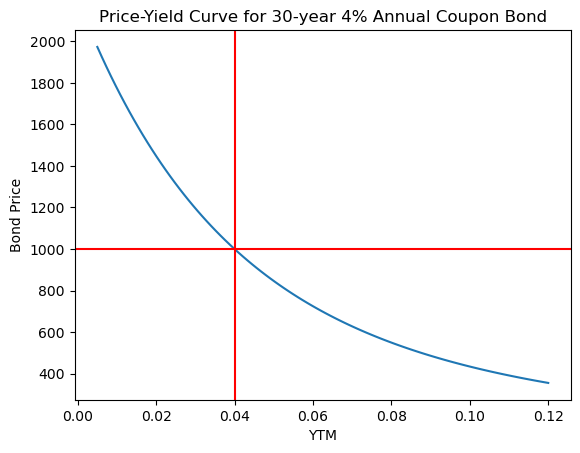

In [20]:
# Plot the price-yield curve
# Add a horizontal line at par (1000) and a vertical line at the coupon rate (4%)

cf_30y = generate_cash_flows(1000, 0.04, 1, 30)
prices_30y = [price_bond(cf_30y, ytm, 1) for ytm in ytms]
plt.plot(ytms, prices_30y)
plt.axhline(y=1000, color='r')
plt.axvline(x=0.04, color='red')
plt.xlabel('YTM')
plt.ylabel('Bond Price')
plt.title('Price-Yield Curve for 30-year 4% Annual Coupon Bond')
plt.show()

# Used a 30-year bond here to make convexity easier to see visually




**"The curve is not a straight line — it's convex. What does that mean in plain English? Why is convexity a good thing for a bondholder?"**

For the bondholder, potential gains are larger than potential losses for equal yield moves on opposite side. In other words, when yields fall by 1% the price of the bond rises more than when the bond loses when yields rise by 1%. This happens because curve is convex, so the slope gets steeper on the left side.



---
## Summary

Write 3-4 sentences explaining what this pricing engine does and why each component matters. What would break if you removed any one of the three functions?

This pricing engine is built on 3 functions. generate_cash_flows derives all the future cash flows up to maturity. price_bond discounts all the cash flows at a given YTM to calculate the market value of the bond. solve_ytm allows to determine the implied yield based on an observed market price. Without these functions, the model would either have no cash flow to value, no way to price the bond, or no way to infer the yield from market prices.